# Relative Rubidium Line fits 

Fits the frequency offset and amplitude scale factor for all other values fixed.

## Imports

In [63]:
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from lmfit.models import ConstantModel, Model
from pathlib import Path
import pandas as pd
from scipy.constants import Boltzmann as kB
from scipy.constants import speed_of_light as c
from scipy.constants import atomic_mass as au
from scipy.constants import epsilon_0 as e0
from scipy.constants import hbar
from scipy.special import voigt_profile
from scipy.signal import find_peaks

def pressure_torr(temp_K: float) -> float:
    if temp_K < 39.31:
        logp = - 94.04826 - 1961.258 / temp_K - \
            0.03771687 * temp_K + 42.57526 * np.log10(temp_K)
    else:
        logp = 15.88253 - 4529.635 / temp_K + 0.00058663 * \
            temp_K - 2.99138 * np.log10(temp_K)
    return 10 ** logp

def transmission_model(x, center, amplitude, sigma, gamma):
    absorption = amplitude * voigt_profile((x-center), sigma, gamma)
    return np.nan_to_num(np.exp(-absorption), nan=0)

def number_density(temp_K: float) -> float:
    return 133.323 * pressure_torr(temp_K) / (kB * temp_K)

## Loading Data and Parameters (Steck)

In [64]:

# datapath = Path(
    # r'/home/mike/Documents/Boulder_PhD/Data/20251030_15h49m14s/rb_cepstral.csv')
datapath = Path( r"C:\Users\mike\Documents\School\Research\Diddams\data\20251030_15h49m14s/rb_cepstral.csv")

data = pd.read_csv(datapath)

full_axis = data['Optical Axis (Hz)'].to_numpy() +3e8
full_spectrum = data[' Real Spectrum'].to_numpy()



# Experimental parameters
temp_K = 273+40 
B_field_gauss = .3
cell_length = .075

mass_85 = au * 84.911789732
mass_87 = au * 86.909180520

ratio_85 = .7217
ratio_87 = 1- ratio_85

nuc_spin_degen_85 = 12
nuc_spin_degen_87 = 8

nu0_D1_85 = 377.10738569e12
nu0_D2_85 = 384.23040637e12

nu0_D1_87 = 377.1074635e12
nu0_D2_87 = 384.2304844685e12

Gamma_D1 = 2 * np.pi * 5.746e6
Gamma_D2 = 2 * np.pi * 6.065e6

lam_D1 = 794.979e-9
lam_D2 = 780.241e-9

dop_sigmav_85 = np.sqrt(kB * temp_K / mass_85) 
dop_sigmav_87 = np.sqrt(kB * temp_K / mass_87)

dipole_mat_element_D1 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D1 * lam_D1**3 / (8 * np.pi**2))
dipole_mat_element_D2 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D2 * lam_D2**3 / (8 * np.pi**2))

# D2 dict

isotopes = {'85': {}, '87': {}}
lines = {'D1': deepcopy(isotopes), 'D2': deepcopy(isotopes)}

lines['D1']['87']['Fg2Fe1'] = {'center': nu0_D1_87 - 2.5630059790891e9 -510.410e6 - .7e6 * B_field_gauss + .23e6 * B_field_gauss, 'cf2': 5/18}
lines['D1']['87']['Fg2Fe2'] = {'center': nu0_D1_87 - 2.5630059790891e9 +306.246e6 - .7e6 * B_field_gauss + .23e6 * B_field_gauss, 'cf2': 5/18}

lines['D1']['85']['Fg3Fe2'] = {'center': nu0_D1_85 - 1.2648885163e9 -210.923e6 -.47e6 * B_field_gauss -.16e6 * B_field_gauss, 'cf2': 35/81}
lines['D1']['85']['Fg3Fe3'] = {'center': nu0_D1_85 - 1.2648885163e9 + 150.659e6 -.47e6 * B_field_gauss +.16e6 * B_field_gauss, 'cf2': 28/81}

lines['D1']['85']['Fg2Fe2'] = {'center': nu0_D1_85 + 1.7708439228e9 -210.923e6+.47e6 * B_field_gauss -.16e6 * B_field_gauss, 'cf2': 10/81}
lines['D1']['85']['Fg2Fe3'] = {'center': nu0_D1_85 + 1.7708439228e9 + 150.659e6+.47e6 * B_field_gauss +.16e6 * B_field_gauss, 'cf2': 35/81}

lines['D1']['87']['Fg1Fe1'] = {'center': nu0_D1_87 + 4.2716766318151e9 -510.410e6 + .7e6 * B_field_gauss +.23e6 * B_field_gauss, 'cf2': 1/18}
lines['D1']['87']['Fg1Fe2'] = {'center': nu0_D1_87  +4.2716766318151e9+306.246e6+ .7e6 * B_field_gauss +.23e6 * B_field_gauss, 'cf2': 5/18}

lines['D2']['87']['Fg2Fe1'] = {'center': nu0_D2_87 - 2.56300597908911e9 -229.8518e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 1/18}
lines['D2']['87']['Fg2Fe2'] = {'center': nu0_D2_87 - 2.56300597908911e9- 72.9113e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 5/18}
lines['D2']['87']['Fg2Fe3'] = {'center': nu0_D2_87  - 2.56300597908911e9+193.7408e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 7/9}

lines['D2']['85']['Fg3Fe2'] = {'center': nu0_D2_85 - 1.264888516e9 -83.955e6  -.47e6 * B_field_gauss +.16e6* B_field_gauss, 'cf2': 10/81}
lines['D2']['85']['Fg3Fe3'] = {'center': nu0_D2_85 - 1.264888516e9 - 20.503e6 -.47e6 * B_field_gauss +.54e6* B_field_gauss, 'cf2': 35/81}
lines['D2']['85']['Fg3Fe4'] = {'center': nu0_D2_85 - 1.264888516e9+ 100.357e6 -.47e6 * B_field_gauss +.70e6* B_field_gauss, 'cf2': 1}

lines['D2']['85']['Fg2Fe1'] = {'center': nu0_D2_85 +1.770843922e9 -113.307e6 +.47e6 * B_field_gauss -1.4e6 * B_field_gauss, 'cf2': 1/3}
lines['D2']['85']['Fg2Fe2'] = {'center': nu0_D2_85 +1.770843922e9-83.955e6+.47e6 * B_field_gauss +.16e6 * B_field_gauss, 'cf2': 35/81}
lines['D2']['85']['Fg2Fe3'] = {'center': nu0_D2_85 +1.770843922e9- 20.503e6+.47e6 * B_field_gauss +.54e6 * B_field_gauss, 'cf2': 28/81}

lines['D2']['87']['Fg1Fe0'] = {'center': nu0_D2_87 +4.27167663181519e9 -302.0738e6 +.7e6 * B_field_gauss, 'cf2': 1/9}
lines['D2']['87']['Fg1Fe1'] = {'center': nu0_D2_87 +4.27167663181519e9-229.8518e6+.7e6 * B_field_gauss+.93e6 * B_field_gauss, 'cf2': 5/18}
lines['D2']['87']['Fg1Fe2'] = {'center': nu0_D2_87 +4.27167663181519e9 - 72.9113e6+.7e6 * B_field_gauss+.93e6 * B_field_gauss, 'cf2': 5/18}

for line, isotopes in lines.items():
    for isotope, transitions in isotopes.items():
        for transition, props in transitions.items():
            if isotope == '85':
                if line == 'D2':
                    props['sigma'] = dop_sigmav_85 * nu0_D2_85 / c
                    props['gamma'] = Gamma_D2/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * ratio_85 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
                    # props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * \
                        # number_density(
                            # temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
                elif line == 'D1':
                    props['sigma'] = dop_sigmav_85 * nu0_D1_85 / c
                    props['gamma'] = Gamma_D1/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * ratio_85 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
                    # props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * \
                        # number_density(
                            # temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
            elif isotope == '87':
                if line == 'D2':
                    props['sigma'] = dop_sigmav_87 * nu0_D2_87 / c
                    props['gamma'] = Gamma_D2/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * ratio_87 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)
                    # props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * \
                        # number_density(
                            # temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)
                elif line == 'D1':
                    props['sigma'] = dop_sigmav_87 * nu0_D1_87 / c
                    props['gamma'] = Gamma_D1/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * ratio_87 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)
                    # props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * \
                        # number_density(
                            # temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)


## Data and parameters (Siddons)

In [68]:
# datapath = Path(
    # r'/home/mike/Documents/Boulder_PhD/Data/20251023_10h18m12s/rb_cepstral.csv')
datapath = Path(
    r"C:\Users\mike\Documents\School\Research\Diddams\data\20251030_15h49m14s/rb_cepstral.csv")
data = pd.read_csv(datapath)
full_axis = data['Optical Axis (Hz)'].to_numpy() +3e8
full_spectrum = data[' Real Spectrum'].to_numpy()

# Experimental parameters
temp_K = 273+30 
cell_length = .075

mass_85 = au * 84.911789732
mass_87 = au * 86.909180520

ratio_85 = .7217
ratio_87 = .2783

nuc_spin_degen_85 = 12
nuc_spin_degen_87 = 8

nu0_D1 = 377107407.299e6
nu0_D2 = 384230426.6e6

Gamma_D1 = 2 * np.pi * 5.746e6
Gamma_D2 = 2 * np.pi * 6.065e6

lam_D1 = 794.979e-9
lam_D2 = 780.241e-9

dop_sigmav_85 = np.sqrt(kB * temp_K / mass_85) 
dop_sigmav_87 = np.sqrt(kB * temp_K / mass_87)

dipole_mat_element_D1 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D1 * lam_D1**3 / (8 * np.pi**2))
dipole_mat_element_D2 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D2 * lam_D2**3 / (8 * np.pi**2))

# D2 dict

isotopes = {'85': {}, '87': {}}
lines = {'D1': deepcopy(isotopes), 'D2': deepcopy(isotopes)}

lines['D1']['87']['Fg2Fe1'] = {'center': nu0_D1 - 3014.644e6, 'cf2': 5/18}
lines['D1']['87']['Fg2Fe2'] = {'center': nu0_D1 - 2202.381e6, 'cf2': 5/18}

lines['D1']['85']['Fg3Fe2'] = {'center': nu0_D1 - 1497.657e6, 'cf2': 35/81}
lines['D1']['85']['Fg3Fe3'] = {'center': nu0_D1 - 1135.721e6, 'cf2': 28/81}

lines['D1']['85']['Fg2Fe2'] = {'center': nu0_D1 + 1538.063e6, 'cf2': 10/81}
lines['D1']['85']['Fg2Fe3'] = {'center': nu0_D1 + 1900.087e6, 'cf2': 35/81}

lines['D1']['87']['Fg1Fe1'] = {'center': nu0_D1 + 3820.046e6, 'cf2': 1/18}
lines['D1']['87']['Fg1Fe2'] = {'center': nu0_D1 + 4632.339e6, 'cf2': 5/18}

lines['D2']['87']['Fg2Fe1'] = {'center': nu0_D2 - 2735.05e6, 'cf2': 1/18}
lines['D2']['87']['Fg2Fe2'] = {'center': nu0_D2 - 2578.11e6, 'cf2': 5/18}
lines['D2']['87']['Fg2Fe3'] = {'center': nu0_D2 - 2311.26e6, 'cf2': 7/9}

lines['D2']['85']['Fg3Fe2'] = {'center': nu0_D2 - 1371.29e6, 'cf2': 10/81}
lines['D2']['85']['Fg3Fe3'] = {'center': nu0_D2 - 1307.87e6, 'cf2': 35/81}
lines['D2']['85']['Fg3Fe4'] = {'center': nu0_D2 - 1186.91e6, 'cf2': 1}

lines['D2']['85']['Fg2Fe1'] = {'center': nu0_D2 + 1635.454e6, 'cf2': 1/3}
lines['D2']['85']['Fg2Fe2'] = {'center': nu0_D2 + 1664.714e6, 'cf2': 35/81}
lines['D2']['85']['Fg2Fe3'] = {'center': nu0_D2 + 1728.134e6, 'cf2': 28/81}

lines['D2']['87']['Fg1Fe0'] = {'center': nu0_D2 + 4027.403e6, 'cf2': 1/9}
lines['D2']['87']['Fg1Fe1'] = {'center': nu0_D2 + 4099.625e6, 'cf2': 5/18}
lines['D2']['87']['Fg1Fe2'] = {'center': nu0_D2 + 4256.57e6, 'cf2': 5/18}

for line, isotopes in lines.items():
    for isotope, transitions in isotopes.items():
        for transition, props in transitions.items():
            if isotope == '85':
                if line == 'D2':
                    props['sigma'] = dop_sigmav_85 * nu0_D2 / c
                    props['gamma'] = Gamma_D2/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * ratio_85 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
                elif line == 'D1':
                    props['sigma'] = dop_sigmav_85 * nu0_D1 / c
                    props['gamma'] = Gamma_D1/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * ratio_85 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
            elif isotope == '87':
                if line == 'D2':
                    props['sigma'] = dop_sigmav_87 * nu0_D2 / c
                    props['gamma'] = Gamma_D2/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * ratio_87 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)
                elif line == 'D1':
                    props['sigma'] = dop_sigmav_87 * nu0_D1 / c
                    props['gamma'] = Gamma_D1/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * ratio_87 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)

## Fit D2s

[[Model]]
    ((((((((((((Model(constant, prefix='bkg_') * Model(transmission_model, prefix='v_Fg3Fe2_85')) * Model(transmission_model, prefix='v_Fg3Fe3_85')) * Model(transmission_model, prefix='v_Fg3Fe4_85')) * Model(transmission_model, prefix='v_Fg2Fe1_85')) * Model(transmission_model, prefix='v_Fg2Fe2_85')) * Model(transmission_model, prefix='v_Fg2Fe3_85')) * Model(transmission_model, prefix='v_Fg2Fe1_87')) * Model(transmission_model, prefix='v_Fg2Fe2_87')) * Model(transmission_model, prefix='v_Fg2Fe3_87')) * Model(transmission_model, prefix='v_Fg1Fe0_87')) * Model(transmission_model, prefix='v_Fg1Fe1_87')) * Model(transmission_model, prefix='v_Fg1Fe2_87'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 38
    # data points      = 121
    # variables        = 3
    chi-square         = 0.16484167
    reduced chi-square = 0.00139696
    Akaike info crit   = -792.425804
    Bayesian info crit = -784.038433
    R-squared          = 0.98525225
[[Variables]]

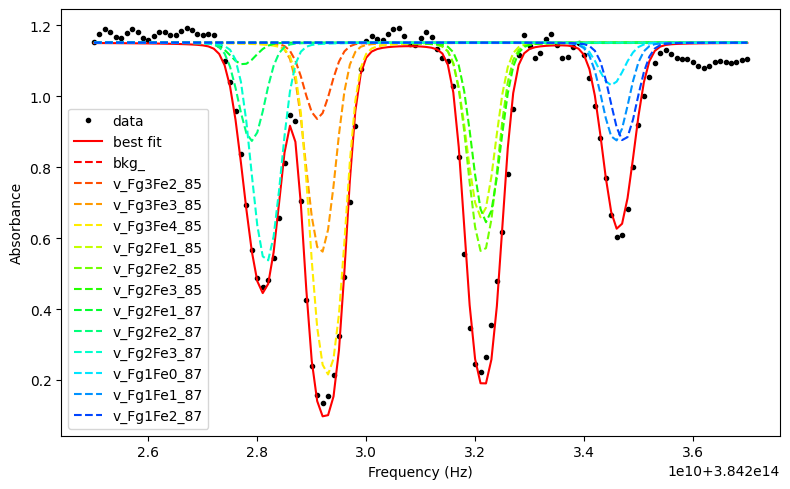

[3.84228060e+14 3.84229194e+14 3.84232102e+14 3.84234579e+14]
[0.44465429 0.09384792 0.18268875 0.62400258]


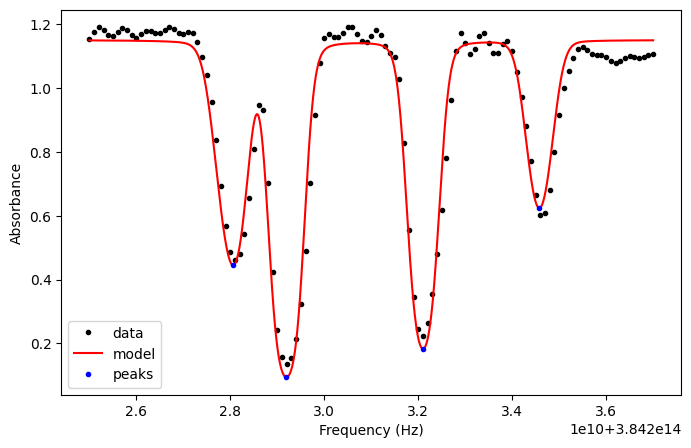

In [69]:
# D2 Fits ######################################3

mask = (full_axis >= 384.225e12) & (full_axis <= 384.237e12)
axis = full_axis[mask] 
spectrum = full_spectrum[mask]
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1)
params.add('xoffset', value=0, min=-500e6, max=500e6)
params.add('amp_scale', value=1e9)

for isotope, transitions in lines['D2'].items():
    for transition, props in transitions.items():
        prefix = f'v_{transition + '_' + isotope}'
        m = Model(transmission_model, prefix=prefix)
        model *= m
        params.update(m.make_params())

        # Give reasonable starting guesses
        params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
        params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
        params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
        params.add(f'{prefix}center_rel', value=props['center'], vary=False)
        params[f'{prefix}center'].expr = f'{prefix}center_rel + xoffset'
        params[f'{prefix}amplitude'].expr = f'{prefix}amp_rel * amp_scale'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(spectrum, params, x=axis)

# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(axis, result.best_fit, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))
components = result.eval_components(x=axis)
yoffset = components['bkg_']
for i, x in enumerate(components.items()):
    name = x[0]
    comp = x[1]
    if i==0:
        plt.plot(axis, np.real(comp) , '--', label=name, color=colors[i])
    else:
        plt.plot(axis, np.real(comp) *yoffset, '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.tight_layout()
plt.show()

# Unshifted line peaks
peak_axis = np.linspace(np.min(axis), np.max(axis), int(1e6))
unshift_params = result.params.copy()
unshift_params['xoffset'].set(value=0)
unshift_spectrum = result.eval(x=peak_axis, params=unshift_params)

peaks_idx, peaks_props = find_peaks(-unshift_spectrum)
peaks_freq = np.array([peak_axis[idx] for idx in peaks_idx])
peaks_amp = result.eval(x=peaks_freq, params=unshift_params)
print(peaks_freq)
print(peaks_amp)
plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(peak_axis, unshift_spectrum, 'r-', label='model')
plt.plot(peaks_freq, peaks_amp, 'b.', label = 'peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.show()

## Fit D1s

[[Model]]
    ((((((((Model(constant, prefix='bkg_') * Model(transmission_model, prefix='v_Fg3Fe2_85')) * Model(transmission_model, prefix='v_Fg3Fe3_85')) * Model(transmission_model, prefix='v_Fg2Fe2_85')) * Model(transmission_model, prefix='v_Fg2Fe3_85')) * Model(transmission_model, prefix='v_Fg2Fe1_87')) * Model(transmission_model, prefix='v_Fg2Fe2_87')) * Model(transmission_model, prefix='v_Fg1Fe1_87')) * Model(transmission_model, prefix='v_Fg1Fe2_87'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 30
    # data points      = 110
    # variables        = 3
    chi-square         = 0.07307527
    reduced chi-square = 6.8295e-04
    Akaike info crit   = -798.842019
    Bayesian info crit = -790.740578
    R-squared          = 0.98362358
[[Variables]]
    bkg_c:                  1.08234889 +/- 0.00325400 (0.30%) (init = 1)
    xoffset:                55822792.2 +/- 4747292.18 (8.50%) (init = 0)
    amp_scale:              97086820.9 +/- 1561473.80 (1.61%)

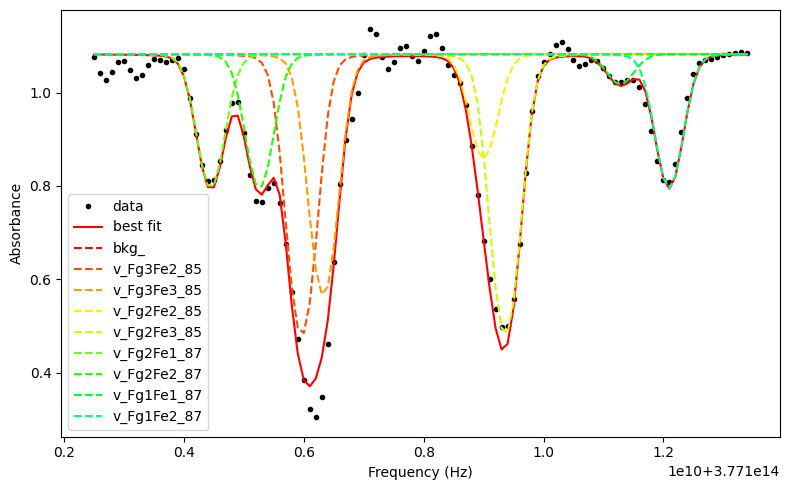

[3.77104395e+14 3.77105223e+14 3.77106034e+14 3.77109276e+14
 3.77111236e+14 3.77112039e+14]
[0.79135539 0.78052682 0.37112609 0.44718615 1.0139544  0.79398683]


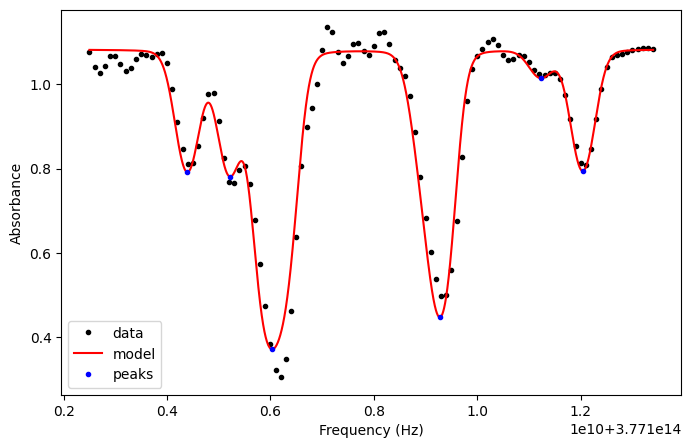

In [67]:
mask = (full_axis >= nu0_D1 - 5e9) & (full_axis <= nu0_D1 + 6e9) 
axis = full_axis[mask]
spectrum = full_spectrum[mask]
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1)
params.add('xoffset', value=0, min=-500e6, max=500e6)
params.add('amp_scale', value=1e9)

for isotope, transitions in lines['D1'].items():
    for transition, props in transitions.items():
        prefix = f'v_{transition + '_' + isotope}'
        m = Model(transmission_model, prefix=prefix)
        model *= m
        params.update(m.make_params())

        # Give reasonable starting guesses
        params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
        params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
        params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
        params.add(f'{prefix}center_rel', value=props['center'], vary=False)
        params[f'{prefix}center'].expr = f'{prefix}center_rel + xoffset'
        params[f'{prefix}amplitude'].expr = f'{prefix}amp_rel * amp_scale'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(spectrum, params, x=axis)

# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

yoffset = result.params['bkg_c'].value
# xoffset = result.params['xoffset'].value
xoffset=0

plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(axis-xoffset, result.best_fit, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))

components = result.eval_components(x=axis)
for i, x in enumerate(components.items()):
    name = x[0]
    comp = x[1]
    if i==0:
        plt.plot(axis-xoffset, np.real(comp) , '--', label=name, color=colors[i])
    else:
        plt.plot(axis-xoffset, np.real(comp) *yoffset, '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.tight_layout()
plt.show()

# Unshifted line peaks
peak_axis = np.linspace(np.min(axis), np.max(axis), int(1e6))
unshift_params = result.params.copy()
unshift_params['xoffset'].set(value=0)
unshift_spectrum = result.eval(x=peak_axis, params=unshift_params)

peaks_idx, peaks_props = find_peaks(-unshift_spectrum)
peaks_freq = np.array([peak_axis[idx] for idx in peaks_idx])
peaks_amp = result.eval(x=peaks_freq, params=unshift_params)
print(peaks_freq)
print(peaks_amp)
plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(peak_axis, unshift_spectrum, 'r-', label='model')
plt.plot(peaks_freq, peaks_amp, 'b.', label = 'peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.show()

# Relative Sodium Line fits (Steck Data)

Fits the frequency offset and amplitude scale factor for all other values fixed.

## Imports and definitions

In [2]:
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from lmfit.models import ConstantModel, Model
from pathlib import Path
import pandas as pd
from scipy.constants import Boltzmann as kB
from scipy.constants import speed_of_light as c
from scipy.constants import atomic_mass as au
from scipy.constants import epsilon_0 as e0
from scipy.constants import hbar
from scipy.special import voigt_profile
from scipy.signal import find_peaks

def pressure_torr(temp_K: float) -> float:
    if temp_K < 273+98:
        logp = 133.42927 - 9302.868 / temp_K + \
            0.03114431 * temp_K - 49.37679 * np.log10(temp_K)
    else:
        logp = 10.86423 - 5619.406 / temp_K + 0.00000345 * \
            temp_K - 1.04111  * np.log10(temp_K)
    return 10 ** logp


def number_density(temp_K: float) -> float:
    return 133.323 * pressure_torr(temp_K) / (kB * temp_K)

def transmission_model(x, center, amplitude, sigma, gamma):
    absorption = amplitude * voigt_profile((x-center), sigma, gamma)
    return np.nan_to_num(np.exp(-absorption), nan=0)

## Loading Data and Parameters

In [4]:

# datapath = Path(
    # r'/home/mike/Documents/Boulder_PhD/Data/20251023_10h18m12s/rb_cepstral.csv')
datapath = Path( r"C:\Users\mike\Documents\School\Research\Diddams\data\20251030_15h49m14s/rb_cepstral.csv")
data = pd.read_csv(datapath)

# Calculated axis
# full_axis = data['Optical Axis (Hz)'].to_numpy()

# 3 Mode offset per Mathieu's suggestiong
full_axis = data['Optical Axis (Hz)'].to_numpy() + 3e8
full_spectrum = data[' Real Spectrum'].to_numpy()

# Experimental parameters
temp_K = 273+100 
B_field_gauss = .3
cell_length = .075

mass = au * 22.9897692807

nuc_spin_degen = 8

nu0_D1 = 508.3324657e12 
nu0_D2 = 508.8487162e12

Gamma_D1 = 2 * np.pi * 9.765e6
Gamma_D2 = 2 * np.pi * 9.795e6

lam_D1 = 589.7566617e-9
lam_D2 = 589.1583264e-9

dop_sigmav_85 = np.sqrt(kB * temp_K / mass) 
dop_sigmav_87 = np.sqrt(kB * temp_K / mass)

dipole_mat_element_D1 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D1 * lam_D1**3 / (8 * np.pi**2))
dipole_mat_element_D2 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D2 * lam_D2**3 / (8 * np.pi**2))

# line info dict


lines = {'D1': {}, 'D2': {}}

lines['D1']['Fg2Fe1'] = {'center': nu0_D1 - 0.6643597983e9 -118.05e6 - .7e6 * B_field_gauss + .23e6 * B_field_gauss, 'cf2': 5/18}
lines['D1']['Fg2Fe2'] = {'center': nu0_D1 - 0.6643597983e9 + 70.83e6 - .7e6 * B_field_gauss + .23e6 * B_field_gauss, 'cf2': 5/18}

lines['D1']['Fg1Fe1'] = {'center': nu0_D1 + 1.1072663305e9  -118.05e6+ .7e6 * B_field_gauss +.23e6 * B_field_gauss, 'cf2': 1/18}
lines['D1']['Fg1Fe2'] = {'center': nu0_D1  + 1.1072663305e9 + 70.83e6+ .7e6 * B_field_gauss +.23e6 * B_field_gauss, 'cf2': 5/18}

lines['D2']['Fg2Fe1'] = {'center': nu0_D2 - 0.6643597983e9 -50.288e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 1/18}
lines['D2']['Fg2Fe2'] = {'center': nu0_D2 - 0.6643597983e9 -15.944e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 5/18}
lines['D2']['Fg2Fe3'] = {'center': nu0_D2 - 0.6643597983e9 + 42.382e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 7/9}

lines['D2']['Fg1Fe0'] = {'center': nu0_D2 + 1.1072663305e9-66.097e6 +.7e6 * B_field_gauss, 'cf2': 1/9}
lines['D2']['Fg1Fe1'] = {'center': nu0_D2 + 1.1072663305e9-50.288e6+.7e6 * B_field_gauss+.93e6 * B_field_gauss, 'cf2': 5/18}
lines['D2']['Fg1Fe2'] = {'center': nu0_D2 + 1.1072663305e9-15.944e6+.7e6 * B_field_gauss+.93e6 * B_field_gauss, 'cf2': 5/18}

for line, transitions in lines.items():
    for transition, props in transitions.items():
        if line == 'D2':
            props['sigma'] = dop_sigmav_85 * nu0_D2 / c
            props['gamma'] = Gamma_D2/2
            props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * \
                number_density(
                    temp_K) / (nuc_spin_degen * hbar * e0 * dop_sigmav_85)
            # props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * \
                # number_density(
                    # temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
        elif line == 'D1':
            props['sigma'] = dop_sigmav_85 * nu0_D1 / c
            props['gamma'] = Gamma_D1/2
            props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * \
                number_density(
                    temp_K) / (nuc_spin_degen * hbar * e0 * dop_sigmav_85)
            # props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * \
                # number_density(
                    # temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)


## Fit D2s

[[Model]]
    ((((((Model(constant, prefix='bkg_') * Model(transmission_model, prefix='v_Fg2Fe1_Fg2Fe1')) * Model(transmission_model, prefix='v_Fg2Fe2_Fg2Fe1')) * Model(transmission_model, prefix='v_Fg2Fe3_Fg2Fe1')) * Model(transmission_model, prefix='v_Fg1Fe0_Fg2Fe1')) * Model(transmission_model, prefix='v_Fg1Fe1_Fg2Fe1')) * Model(transmission_model, prefix='v_Fg1Fe2_Fg2Fe1'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 8000
    # data points      = 1000
    # variables        = 3
    chi-square         = 535.029667
    reduced chi-square = 0.53663959
    Akaike info crit   = -619.433081
    Bayesian info crit = -604.709816
    R-squared          = -5.3503e+17
##  Warning: uncertainties could not be estimated:
    bkg_c:                      at boundary
[[Variables]]
    bkg_c:                      0.90000687 (init = 1)
    xoffset:                    250.182006 (init = 0)
    amp_scale:                  3.4286e+10 (init = 1e+09)
    v_Fg2Fe1_Fg2Fe1cen

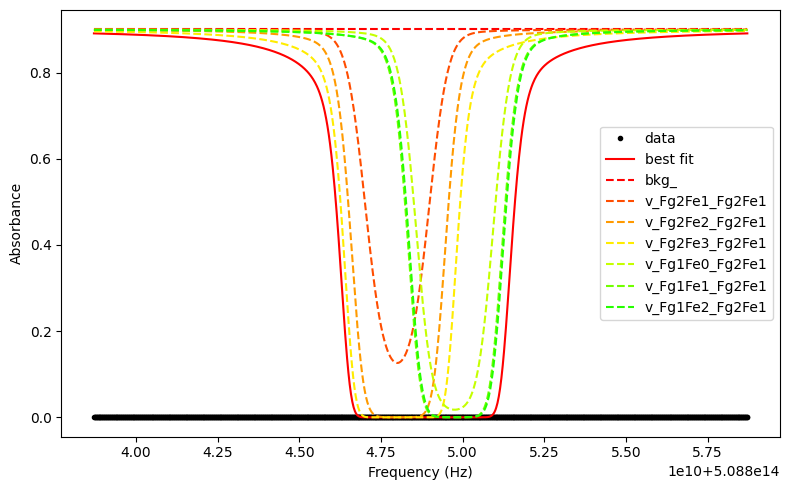

[5.08848107e+14 5.08849666e+14]
[0.27955933 0.43236999]


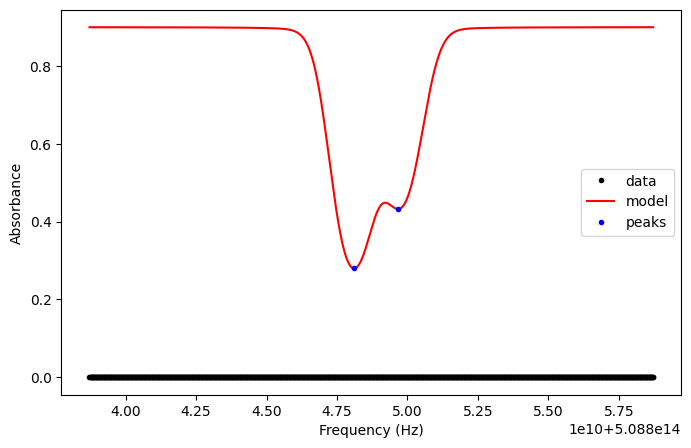

In [ ]:
min_freq=nu0_D2 - 10e9
max_freq=nu0_D2 + 10e9
npts=1000
mask = (full_axis >= min_freq) & (full_axis <= max_freq) 
# axis = full_axis[mask]
axis = np.linspace(min_freq, max_freq, npts)
# spectrum = full_spectrum[mask]
spectrum = np.zeros(npts)
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1, min=.9, max=1.1)
params.add('xoffset', value=0, min=-500e6, max=500e6, vary=False)
params.add('amp_scale', value=1e9)
# params.add('Rb87_ratio', value=ratio_87, max=ratio_87+.1, min=ratio_87-.1)

for transition, props in lines['D2'].items():
    prefix = f'v_{transition + '_' + line}'
    m = Model(transmission_model, prefix=prefix)
    model *= m
    params.update(m.make_params())

    # Give reasonable starting guesses
    params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
    params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
    params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
    params.add(f'{prefix}center_rel', value=props['center'], vary=False)
    params[f'{prefix}center'].expr = f'{prefix}center_rel + xoffset'
    params[f'{prefix}amplitude'].expr = f'{prefix}amp_rel * amp_scale'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(spectrum, params, x=axis)

# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(axis, result.best_fit, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))
components = result.eval_components(x=axis)
yoffset = components['bkg_']
for i, x in enumerate(components.items()):
    name = x[0]
    comp = x[1]
    if i==0:
        plt.plot(axis, np.real(comp) , '--', label=name, color=colors[i])
    else:
        plt.plot(axis, np.real(comp) *yoffset, '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.tight_layout()
plt.show()

# Unshifted line peaks
peak_axis = np.linspace(np.min(axis), np.max(axis), int(1e7))
unshift_params = result.params.copy()
unshift_params['xoffset'].set(value=0)
unshift_params['amp_scale'].set(value=1e9)
unshift_spectrum = result.eval(x=peak_axis, params=unshift_params)

peaks_idx, peaks_props = find_peaks(-unshift_spectrum)
peaks_freq = np.array([peak_axis[idx] for idx in peaks_idx])
peaks_amp = result.eval(x=peaks_freq, params=unshift_params)
print(peaks_freq)
print(peaks_amp)
plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(peak_axis, unshift_spectrum, 'r-', label='model')
plt.plot(peaks_freq, peaks_amp, 'b.', label = 'peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.show()

## Fit D1s

[[Model]]
    ((((Model(constant, prefix='bkg_') * Model(transmission_model, prefix='v_Fg2Fe1_Fg2Fe1')) * Model(transmission_model, prefix='v_Fg2Fe2_Fg2Fe1')) * Model(transmission_model, prefix='v_Fg1Fe1_Fg2Fe1')) * Model(transmission_model, prefix='v_Fg1Fe2_Fg2Fe1'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 8000
    # data points      = 1000
    # variables        = 3
    chi-square         = 553.435906
    reduced chi-square = 0.55510121
    Akaike info crit   = -585.609331
    Bayesian info crit = -570.886065
    R-squared          = -5.5344e+17
##  Warning: uncertainties could not be estimated:
    bkg_c:                      at boundary
[[Variables]]
    bkg_c:                      0.90000480 (init = 1)
    xoffset:                    245.024795 (init = 0)
    amp_scale:                  4.3287e+10 (init = 1e+09)
    v_Fg2Fe1_Fg2Fe1center:      5.0833e+14 == 'v_Fg2Fe1_Fg2Fe1center_rel + xoffset'
    v_Fg2Fe1_Fg2Fe1amplitude:   2.0158e+10 == 'v_F

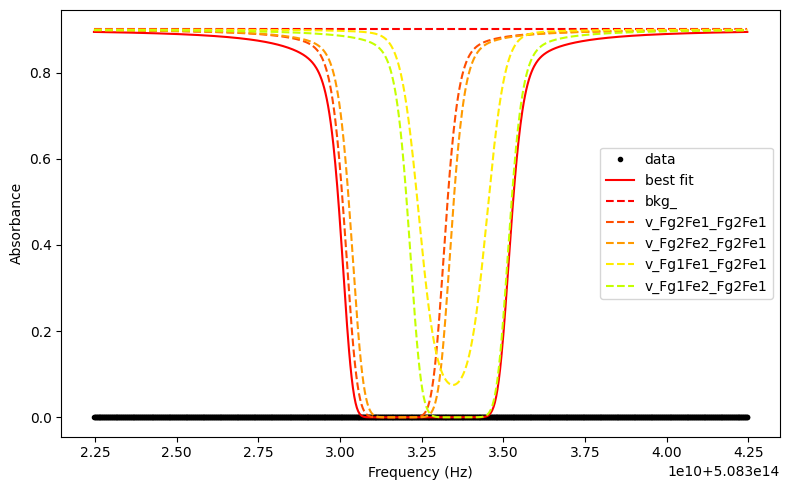

[5.08331798e+14 5.08333546e+14]
[0.50625328 0.63012216]


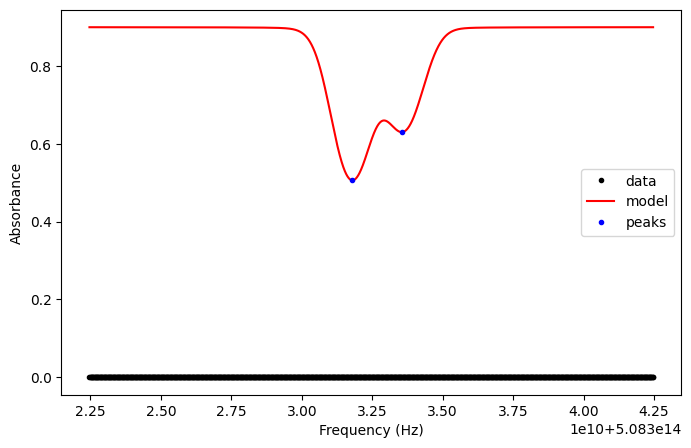

In [17]:
min_freq=nu0_D1 - 10e9
max_freq=nu0_D1 + 10e9
npts=1000
mask = (full_axis >= min_freq) & (full_axis <= max_freq) 
# axis = full_axis[mask]
axis = np.linspace(min_freq, max_freq, npts)
# spectrum = full_spectrum[mask]
spectrum = np.zeros(npts)
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1, min=.9, max=1.1)
params.add('xoffset', value=0, min=-500e6, max=500e6)
params.add('amp_scale', value=1e9)

for transition, props in lines['D1'].items():
    prefix = f'v_{transition + '_' + isotope}'
    m = Model(transmission_model, prefix=prefix)
    model *= m
    params.update(m.make_params())

    # Give reasonable starting guesses
    params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
    params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
    params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
    params.add(f'{prefix}center_rel', value=props['center'], vary=False)
    params[f'{prefix}center'].expr = f'{prefix}center_rel + xoffset'
    params[f'{prefix}amplitude'].expr = f'{prefix}amp_rel * amp_scale'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(spectrum, params, x=axis)

# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

yoffset = result.params['bkg_c'].value
# xoffset = result.params['xoffset'].value
xoffset=0

plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(axis-xoffset, result.best_fit, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))

components = result.eval_components(x=axis)
for i, x in enumerate(components.items()):
    name = x[0]
    comp = x[1]
    if i==0:
        plt.plot(axis-xoffset, np.real(comp) , '--', label=name, color=colors[i])
    else:
        plt.plot(axis-xoffset, np.real(comp) *yoffset, '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.tight_layout()
plt.show()

# Unshifted line peaks
peak_axis = np.linspace(np.min(axis), np.max(axis), int(1e7))
unshift_params = result.params.copy()
unshift_params['xoffset'].set(value=0)
unshift_params['amp_scale'].set(value=1e9)
unshift_spectrum = result.eval(x=peak_axis, params=unshift_params)

peaks_idx, peaks_props = find_peaks(-unshift_spectrum)
peaks_freq = np.array([peak_axis[idx] for idx in peaks_idx])
peaks_amp = result.eval(x=peaks_freq, params=unshift_params)
print(peaks_freq)
print(peaks_amp)
plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(peak_axis, unshift_spectrum, 'r-', label='model')
plt.plot(peaks_freq, peaks_amp, 'b.', label = 'peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.show()

# Raw Data

## Imports and functions

In [27]:
import numpy as np
from numpy.fft import fftshift, fft, rfft, irfft, fftfreq
from numpy.typing import NDArray
import json
from pathlib import Path
from scipy.constants import speed_of_light as C_MKS

def load_avg_pug_bin(path: Path) -> NDArray[np.complex128]:
    """
    Loads and averages all data files under the pug directory.

    Args:
        path (Path): Path to the directory containing the .bin files, typ. 
        'Channel1'.

    Returns:
        NDArray[np.complex128]: Averaged and carrier-offset interferogram.
    """
    data_files = path.glob('*.bin')
    data_list = []
    for fname in data_files:
        data_list.append(load_pug_bin(fname))

    # Handle different lengths by padding with NaN
    max_len = max(len(d) for d in data_list)
    matrix = np.full((max_len, len(data_list)), np.nan, dtype=complex)

    for i, d in enumerate(data_list):
        matrix[:len(d), i] = d

    # Compute average across files (ignoring NaNs for uneven lengths)
    avg_signal = np.nanmean(matrix, axis=1)
    return avg_signal

def load_pug_bin(path: Path) -> NDArray[np.complex128]:
    """
    Loads a single .bin file in the method used by the PUG.

    Args:
        path (Path): Path to the .bin file.

    Returns:
        NDArray[np.complex128]: Carrier-subtracted interferogram.
    """
    # Load raw binary floats (32-bit)
    numbers = np.fromfile(path, dtype=np.float32)

    # Convert to complex: (real, imag) pairs
    complex_data = numbers[0::2] + 1j * numbers[1::2]
    return complex_data

def load_json(path: Path) -> dict:
    """
    Loads a .json file as a dictionary.

    Args:
        path (Path): Path to .json file.

    Returns:
        dict: Contents of the file.
    """
    with open(path, 'r') as f:
        return json.load(f)                                                        

def load_pug(path) -> tuple[dict, NDArray] | tuple[None, None]:
    """
    Opens a dialog to ask the user for the PUG's data directory. Loads data exported from the PUG.

    Returns:
        tuple[dict, NDArray]|tuple[None,None]: A parameter dictionary and a complex,
        averaged data array. Returns None for both if the dialog is canceled.
    """
    apriori = load_json(path / 'apriori_params.json')
    computed =load_json(path / 'computed_params.json')
    gage = load_json(path / 'gageCard_params.json')
    avg_data = load_avg_pug_bin(path / 'Output_data/Channel1')
    params = {}
    params.update(apriori)
    params.update(computed)
    params.update(gage)
    return params, avg_data

def calc_absorbance(spectrum):
    """
    Calculates the absorbance of the spectrum and updates internal variables.
    """

    return - np.log(spectrum) 

def calc_cepstral_modified_igm(absorbance, optical_axis, time_axis, freq_cuton: float, freq_cutoff: float): 
    """
    Calculates the modified igm based on the absorbance and updates internal values for
    it and the associated time and frequency axes.

    Args:
        freq_cuton (flaot): Start of the absorbance window 
        freq_cutoff (float): End of the absorbance window
    """
    # Cut axis and absorbance based on window bounds
    mask = (optical_axis >= freq_cuton) & (optical_axis <= freq_cutoff)
    cepstral_optical_axis = optical_axis[mask]
    absorbance_cut = absorbance[mask]

    # Calculate modified igm
    mod_igm = irfft(absorbance_cut)

    # Calculate time axis
    cep_time_axis = np.linspace(
        time_axis[0], time_axis[-1], len(mod_igm))

    # Update internal variables
    cepstral_time_axis = cep_time_axis
    mod_igm = mod_igm
    return mod_igm, cepstral_optical_axis, cepstral_time_axis

def calc_cepstral_spectrum(mod_igm, cep_time_axis, time_cutons: float, time_cutoffs:float, filter='step'):
    """
    Calculates the background-subtracted spectrum and updates internal variables.

    Args:
        time_cutons (float): Start of 
        time_cutoffs (float): _description_
        filter (str, optional): _description_. Defaults to 'step'.

    Raises:
        ValueError: _description_
    """        
    if not isinstance(time_cutons, (list, tuple)):
        cutons = [time_cutons]
    else:
        cutons = time_cutons

    if not isinstance(time_cutoffs, (list, tuple)):
        cutoffs = [time_cutoffs]
    else:
        cutoffs = time_cutoffs


    for cuton, cutoff in zip(cutons, cutoffs):
        if filter == 'step':
            mask = (cep_time_axis >= cuton) & (cep_time_axis <= cutoff)
            mod_igm[mask] = 0
        else:
            raise ValueError(
                f'\"{filter}\" is not a valid input for argument filter')

    cepstral_absorbance = -rfft(mod_igm)
    return np.abs(np.exp(cepstral_absorbance))  


## Analysis

1934050


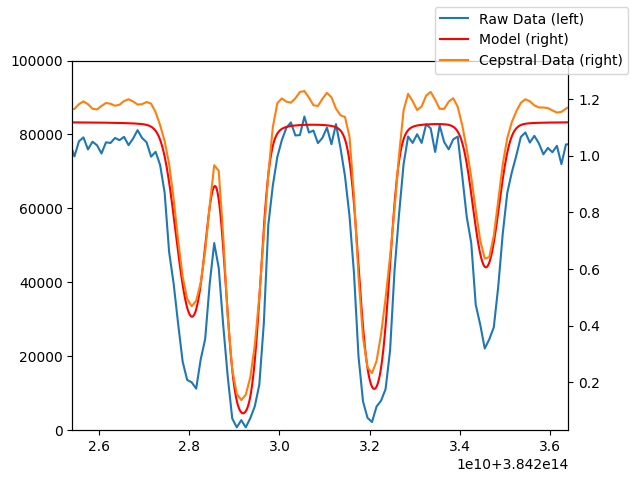

In [62]:
path = Path(r"C:\Users\mike\Documents\School\Research\Diddams\data\20251030_15h49m14s")

params, avg_signal = load_pug(path)
fb1 = -36e6
fb2 = 27e6
f01 = -35e6
f02 = -36e6
fr1 = params['fr_approx_Hz']
dfr = params['dfr']
sample_rate = params['sampling_rate_Hz']
nu_cw = C_MKS / params['reference1_laser_wvl_nm'] * 1e9
cw_mode1 = round((nu_cw + fb1 - f01) / fr1)
print(cw_mode1)
harmonic = params['nb_harmonic']

ppigm = len(avg_signal)

electrical_axis = fftshift(
    fftfreq(ppigm, d=1/sample_rate))
axis_norm = fftshift(fftfreq(ppigm))
axis_N = axis_norm * ppigm
axis_shift = harmonic * ((cw_mode1) * fr1 + f01) + 3 * fr1 

# Still need to derive extra mode offset
raw_optical_axis = (axis_N ) * fr1 + axis_shift

raw_spectrum = np.abs(fftshift(fft(avg_signal)))

absorbance = calc_absorbance(raw_spectrum)

time_axis = np.linspace(0, 1/ sample_rate, ppigm)
freq_cuton, freq_cutoff = (nu0_D1_85- 10e9, nu0_D2_87 + 10e9)
mod_igm, cepstral_optical, cepstral_time = calc_cepstral_modified_igm(absorbance, raw_optical_axis, time_axis, freq_cuton, freq_cutoff)

time_cutons, time_cutoffs = ([0, 2e-9], [1e-11 ,1/sample_rate])
cepstral_spectrum = calc_cepstral_spectrum(mod_igm, cepstral_time, time_cutons, time_cutoffs)
# Plot comparison
f, ax = plt.subplots()
ax2 = plt.twinx()
ax.plot(raw_optical_axis, raw_spectrum, color='tab:blue', label="Raw Data (left)")
ax2.plot(peak_axis, unshift_spectrum, 'r-', label='Model (right)')
ax2.plot(cepstral_optical, cepstral_spectrum, color='tab:orange', label='Cepstral Data (right)')
ax.set_xlim(nu0_D2_85 - 5e9, nu0_D2_85 + 6e9)
ax.set_ylim(0, 1e5)
f.legend()
